# Titanic Dataset

## 1) Exploring Titanic Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic = sns.load_dataset('titanic')

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.columns = [column.lower() for column in titanic.columns]
print(titanic.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [5]:
# dowload the dataset
titanic.to_csv('titanic_data.csv', index=False)

In [6]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
titanic.dtypes.value_counts()

object      5
int64       4
float64     2
bool        2
category    1
category    1
Name: count, dtype: int64

In [8]:
null_values = titanic.isnull().sum().sort_values(ascending=False)
print(null_values)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64


In [9]:
titanic.nunique().sort_values(ascending=False)


fare           248
age             88
sibsp            7
parch            7
deck             7
pclass           3
embarked         3
class            3
who              3
embark_town      3
survived         2
sex              2
adult_male       2
alive            2
alone            2
dtype: int64

Text(38.99532214506172, 0.5, 'Count of Passengers')

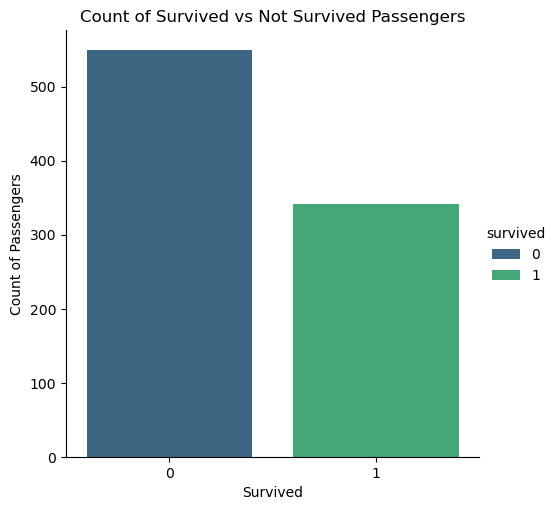

In [10]:
sns.catplot(data=titanic, x="survived", kind="count", hue="survived", palette="viridis")
plt.title('Count of Survived vs Not Survived Passengers')
plt.xlabel('Survived')
plt.ylabel('Count of Passengers')

Text(36.536375, 0.5, 'Count of Passengers')

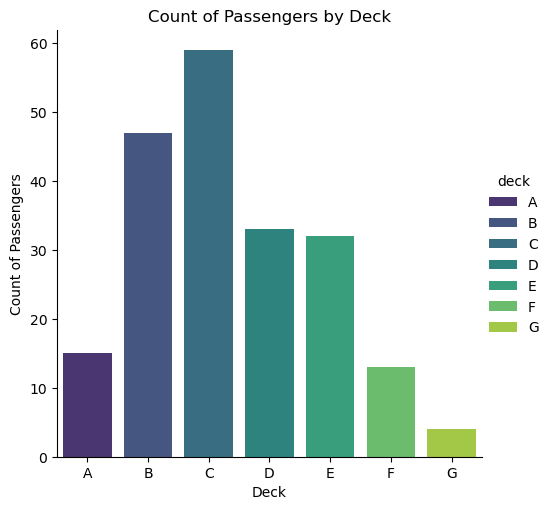

In [11]:
sns.catplot(data=titanic, x="deck", kind="count", hue="deck", palette="viridis")
plt.title('Count of Passengers by Deck')
plt.xlabel('Deck')
plt.ylabel('Count of Passengers')

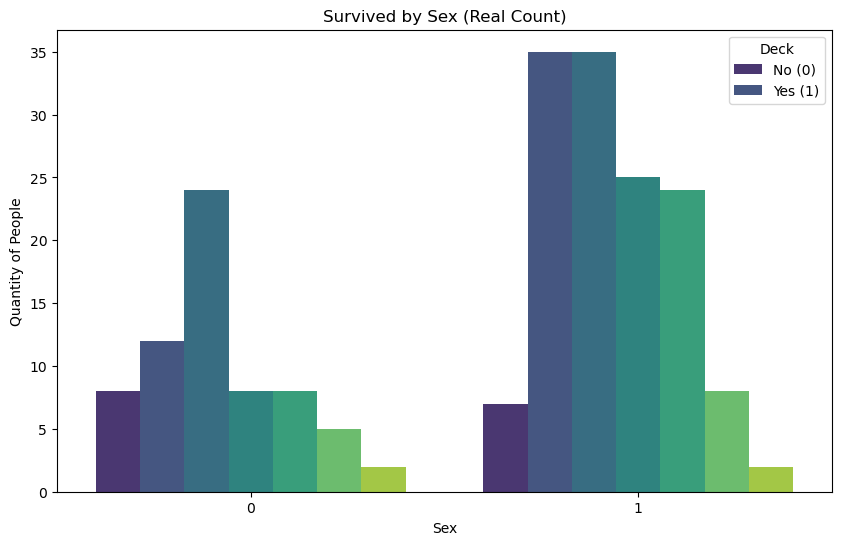

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='survived', hue='deck', palette='viridis')
plt.title('Survived by Sex (Real Count)')
plt.xlabel('Sex')
plt.ylabel('Quantity of People')
plt.legend(title='Deck', labels=['No (0)', 'Yes (1)'])
plt.show()

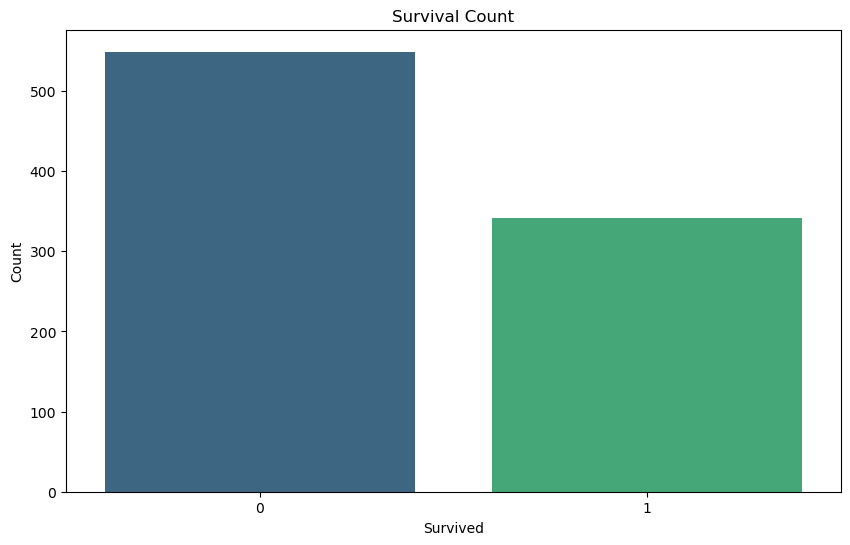

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='survived', hue='survived', palette='viridis', legend=False)
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

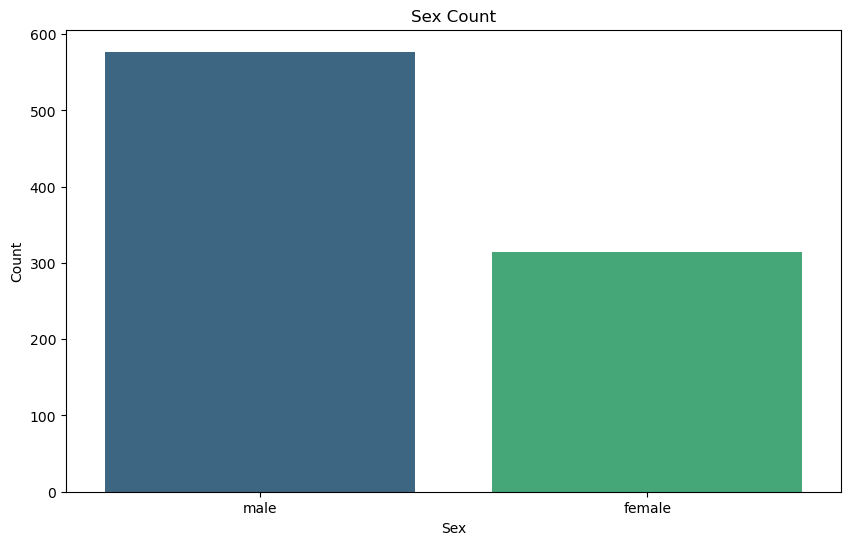

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='sex', hue='sex', palette='viridis', legend=False)
plt.title('Sex Count')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

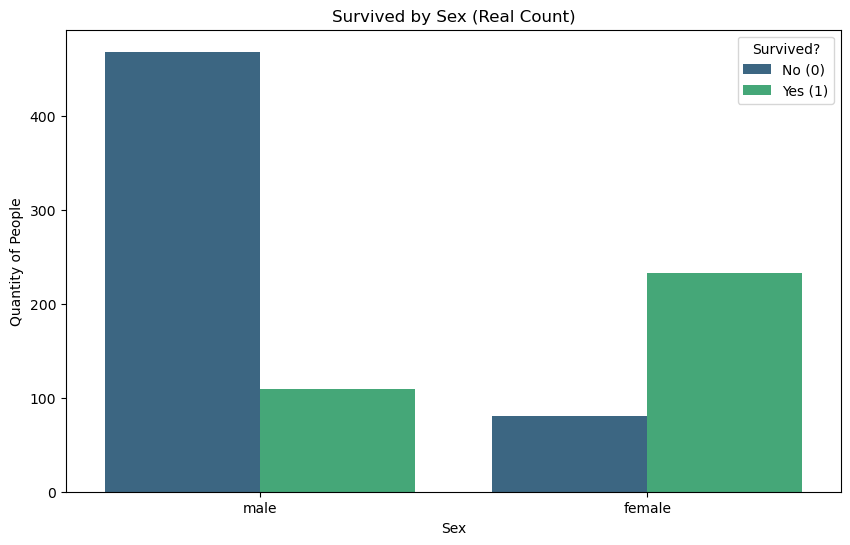

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='sex', hue='survived', palette='viridis')
plt.title('Survived by Sex (Real Count)')
plt.xlabel('Sex')
plt.ylabel('Quantity of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])
plt.show()

In [16]:
min_age = titanic['age'].min()
max_age = titanic['age'].max()
average_age = titanic['age'].mean()
print(f'Minimum age: {min_age}\nMaximum age: {max_age}\nAverage age: {average_age:.2f}')

Minimum age: 0.42
Maximum age: 80.0
Average age: 29.70


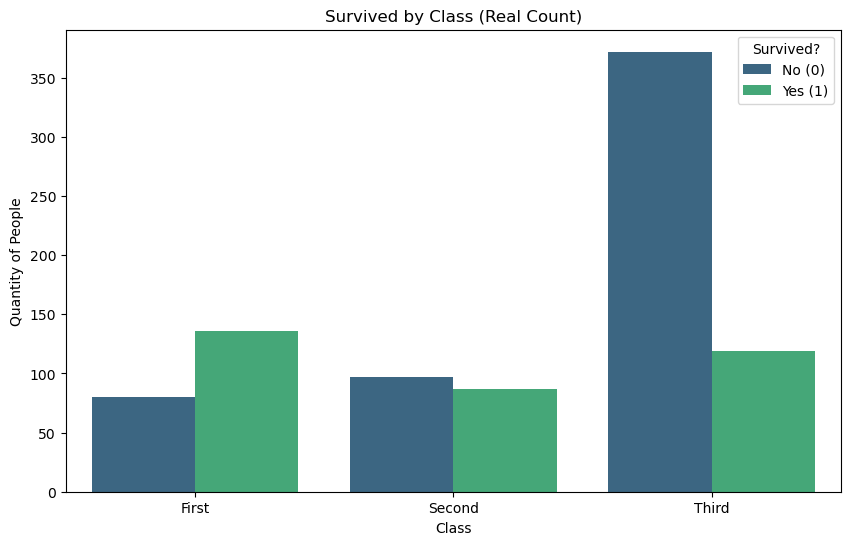

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='class', hue='survived', palette='viridis')
plt.title('Survived by Class (Real Count)')
plt.xlabel('Class')
plt.ylabel('Quantity of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])
plt.show()

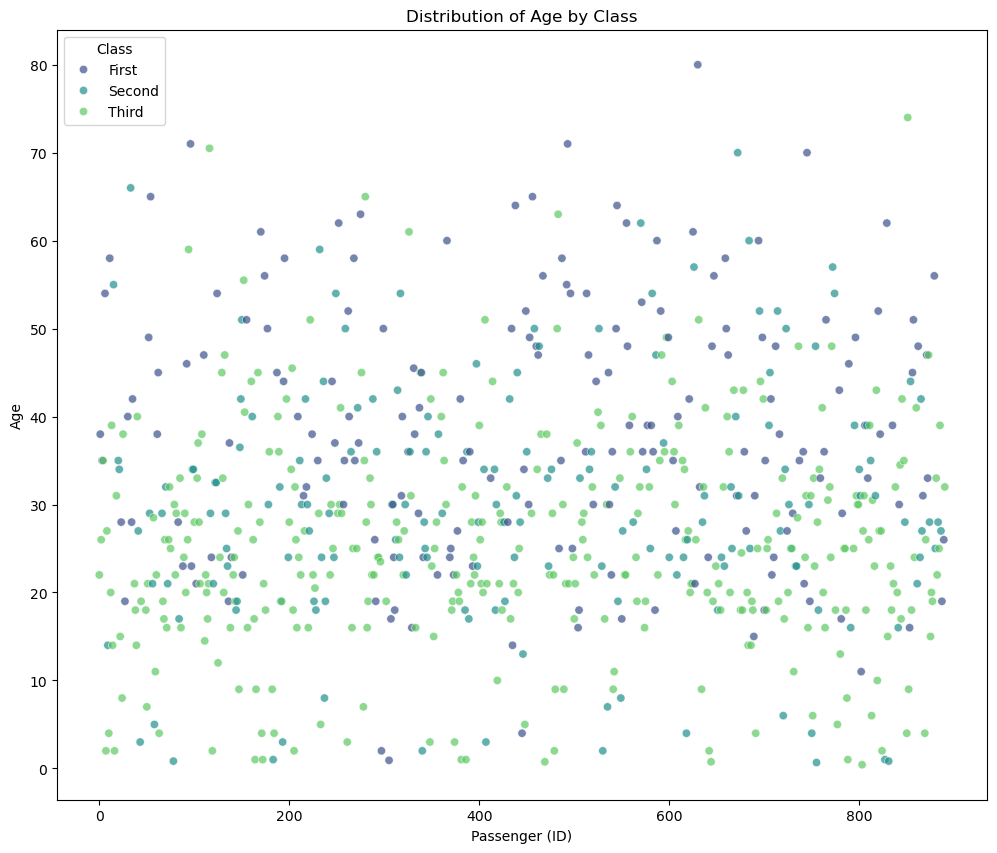

In [18]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=titanic.reset_index(), x='index', y='age', hue='class', palette='viridis', alpha=0.7)
plt.title('Distribution of Age by Class')
plt.xlabel('Passenger (ID)')
plt.ylabel('Age')
plt.legend(title='Class')
plt.show()

## 2) Cleaning and Data Treatment

In [19]:
titanic_filtered = titanic.copy()

In [20]:
titanic_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Handling Null Values

In [21]:
null_values = titanic_filtered.isnull().sum()
print(null_values)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


- We have both age and embarked null values. We will handle differently each case.

In [22]:
mode_embarked = titanic_filtered['embarked'].mode()[0]
titanic_filtered['embarked'] = titanic_filtered['embarked'].fillna(mode_embarked)


- How embarked is a qualitative category, I choose the mode to replace null values.

In [23]:
mean_age_class = titanic_filtered.groupby('pclass', observed=False)['age'].mean().reset_index()
print(mean_age_class)

   pclass        age
0       1  38.233441
1       2  29.877630
2       3  25.140620


In [24]:
titanic_filtered['age'] = titanic_filtered.apply(lambda row: mean_age_class.loc[mean_age_class['pclass'] == row['pclass'], 'age'].values[0] 
                          if pd.isnull(row['age']) else row['age'], axis=1)

- How age is a quantitative category, I choose the age mean of class to replace null values.

In [25]:
titanic_filtered.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

- Now, we have a clean dataset without null values, and we can proceed with further analysis or modeling.

## 3) Feature Engineering

### We must handle quantitative values. 

In [26]:
age_bins = [0, 12, 18, 35, 60, np.inf]
age_labels = ['0-12', '13-18', '19-35', '36-60', '60+']
titanic_filtered['age_group'] = pd.cut(titanic_filtered['age'], bins=age_bins, labels=age_labels)
titanic_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,19-35
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,36-60
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,19-35
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,19-35
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,19-35


In [27]:
fare_bins = [0, 7.91, 14.454, 31, np.inf]
fare_labels = ['0-7.91', '7.91-14.454', '14.454-31', '31+']
titanic_filtered['fare_group'] = pd.cut(titanic_filtered['fare'], bins=fare_bins, labels=fare_labels)
titanic_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,fare_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,19-35,0-7.91
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,36-60,31+
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,19-35,7.91-14.454
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,19-35,31+
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,19-35,7.91-14.454


### Creat a new category: familysize

In [28]:
# 1. Feature Engineering: FamilySize Categories
# Adding 1 for the passenger themselves
titanic_filtered['familysize_num'] = titanic_filtered['sibsp'] + titanic_filtered['parch'] + 1

# Creating the categorical 'FamilySize'
# Bins: 0-1 (Alone), 1-4 (Small), 4-20 (Big)
bins = [0, 1, 4, 20]
labels = ['alone', 'small', 'big']
titanic_filtered['familysize'] = pd.cut(titanic_filtered['familysize_num'], bins=bins, labels=labels)
titanic_filtered.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,fare_group,familysize_num,familysize
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,19-35,0-7.91,2,small
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,36-60,31+,2,small
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,19-35,7.91-14.454,1,alone
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,19-35,31+,2,small
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,19-35,7.91-14.454,1,alone


In [29]:
# Columns for analysis
for column in ['pclass', 'sex','who', 'embarked', 'age_group', 'fare_group', 'familysize']:
    survival = titanic_filtered.groupby(column, observed=False)['survived'].mean().reset_index()
    print(f'Survival by {column}:\n{survival}\n')

Survival by pclass:
   pclass  survived
0       1  0.629630
1       2  0.472826
2       3  0.242363

Survival by sex:
      sex  survived
0  female  0.742038
1    male  0.188908

Survival by who:
     who  survived
0  child  0.590361
1    man  0.163873
2  woman  0.756458

Survival by embarked:
  embarked  survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009

Survival by age_group:
  age_group  survived
0      0-12  0.579710
1     13-18  0.428571
2     19-35  0.346535
3     36-60  0.408889
4       60+  0.227273

Survival by fare_group:
    fare_group  survived
0       0-7.91  0.206731
1  7.91-14.454  0.308756
2    14.454-31  0.445415
3          31+  0.581081

Survival by familysize:
  familysize  survived
0      alone  0.303538
1      small  0.578767
2        big  0.161290



## 4) Saving Dataset

In [30]:
final_titanic = titanic_filtered[['survived','pclass', 'who', 'embarked', 'age_group', 'fare_group', 'familysize']]
final_titanic.head()
# Dowload the final dataset
final_titanic.to_csv('titanic_final.csv', index=False)

## 5) Analyses and Graphs of Processed Data from the Titanic

In [31]:
# Data Validation: Load the final dataset
titanic_data = pd.read_csv('titanic_final.csv')
titanic_data.head()

,survived,pclass,who,embarked,age_group,fare_group,familysize
0,0,3,man,S,19-35,0-7.91,small
1,1,1,woman,C,36-60,31+,small
2,1,3,woman,S,19-35,7.91-14.454,alone
3,1,1,woman,S,19-35,31+,small
4,0,3,man,S,19-35,7.91-14.454,alone


In [32]:
# Checking unique values in each column to validate the data
for column in titanic_data.columns:
    print(f'Unique values in {column}: {titanic_data[column].unique()}')

Unique values in survived: [0 1]
Unique values in pclass: [3 1 2]
Unique values in who: ['man' 'woman' 'child']
Unique values in embarked: ['S' 'C' 'Q']
Unique values in age_group: ['19-35' '36-60' '0-12' '13-18' '60+']
Unique values in fare_group: ['0-7.91' '31+' '7.91-14.454' '14.454-31' nan]
Unique values in familysize: ['small' 'alone' 'big']


### Class Survived
- The most of survived people are who had more money.

   pclass  survived
0       1       216
1       2       184
2       3       491


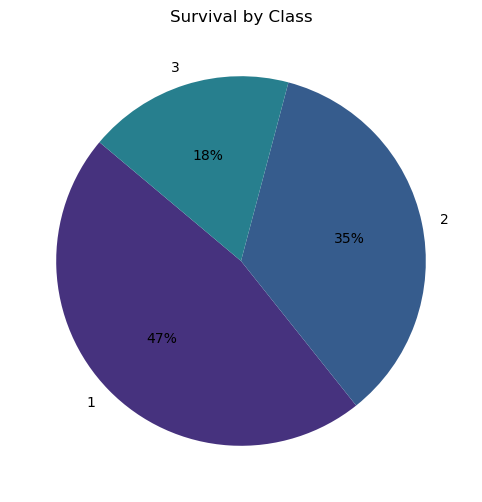

In [33]:
table_by_class = titanic_data.groupby('pclass', observed=False)['survived'].count().reset_index()
print(table_by_class)
survival_by_class = titanic_data.groupby('pclass', observed=False)['survived'].mean().reset_index()
# Define colors for the pie chart
color = sns.color_palette('viridis')[0:4]
# Create the pie chart with Matplotlib
plt.figure(figsize=(8, 6))
plt.pie(survival_by_class['survived'], labels=survival_by_class['pclass'], colors=color, autopct='%.0f%%', startangle=140)
plt.title('Survival by Class')
plt.show()

### Who Survived
- The most of survived are women.

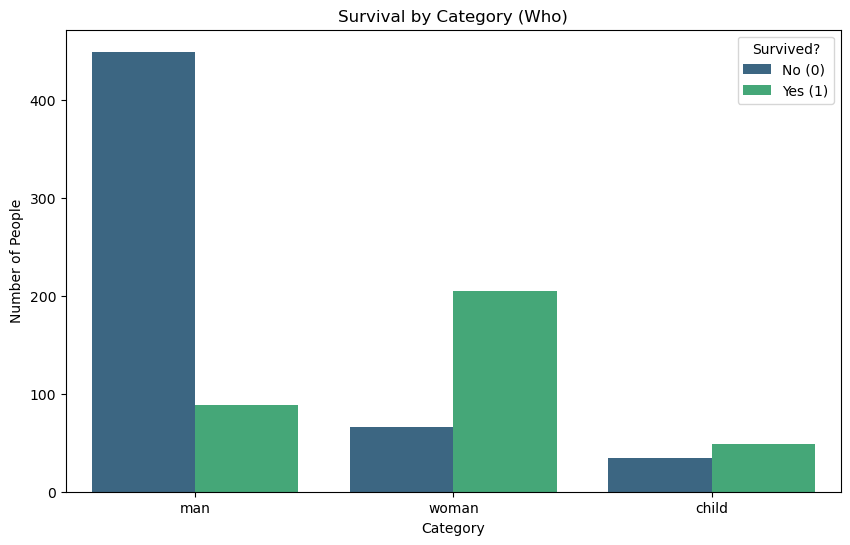

In [34]:
# Size figure
plt.figure(figsize=(10, 6))

# hue='survived'
# The x='who' creates groups (man, woman, child)
# The hue='survived' creates comparison bars within each group
sns.countplot(data=titanic_data, x='who', hue='survived', palette='viridis')

# Improving the chart
plt.title('Survival by Category (Who)')
plt.xlabel('Category')
plt.ylabel('Number of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])

plt.show()

### Embarked

  embarked  survived
0        C       168
1        Q        77
2        S       646


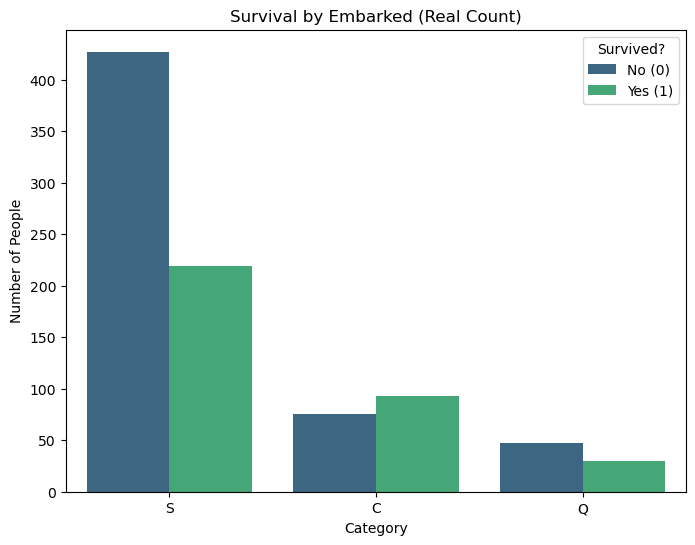

In [35]:
table_by_embarked = titanic_data.groupby('embarked', observed=False)['survived'].count().reset_index()
print(table_by_embarked)
# Create the pie chart with Matplotlib
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic_data, x='embarked', hue='survived', palette='viridis')
plt.title('Survival by Embarked (Real Count)')
plt.xlabel('Category')
plt.ylabel('Number of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])
plt.show()

### Age Group


  age_group  survived
0      0-12        69
1     13-18        70
2     19-35       505
3     36-60       225
4       60+        22


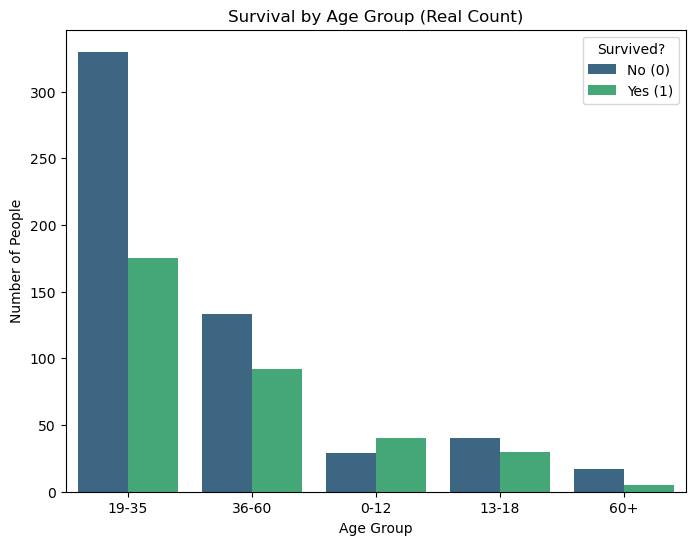

In [36]:
table_by_age_group= titanic_data.groupby('age_group', observed=False)['survived'].count().reset_index()
print(table_by_age_group)
# Create the pie chart with Matplotlib
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic_data, x='age_group', hue='survived', palette='viridis')
plt.title('Survival by Age Group (Real Count)')
plt.xlabel('Age Group')
plt.ylabel('Number of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])
plt.show()

### Fare Group

    fare_group  survived
0       0-7.91       208
1    14.454-31       229
2          31+       222
3  7.91-14.454       217


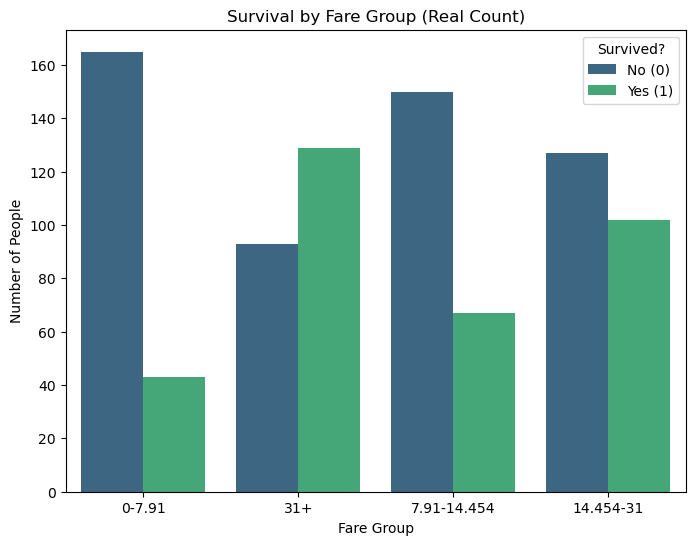

In [37]:
table_by_fare_group= titanic_data.groupby('fare_group', observed=False)['survived'].count().reset_index()
print(table_by_fare_group)
# Create the pie chart with Matplotlib
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic_data, x='fare_group', hue='survived', palette='viridis')
plt.title('Survival by Fare Group (Real Count)')
plt.xlabel('Fare Group')
plt.ylabel('Number of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])
plt.show()

## 6) Conclusion

We observed that the survival rates varied significantly across different categories. 
- For instance **passengers in first class** had a much **higher survival** rate compared to those in second and third class.
- Additionally women had a much higher survival rate than men, and children also had a higher survival rate compared to adults.
